# The Quantum Weighted-Sum Operator

**Notebook 5** of a series implementing **Stamatopoulos et al., *"Option Pricing using Quantum Computers"*** [arXiv:1905.02666](https://arxiv.org/abs/1905.02666), Appendix A.

A companion write-up is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/implementing-option-pricing-using-quantum-computers-in-qiskit-part-4-the-quantum-weighted-sum-bd78812e44c0).

Basket options (Section 4.2.1) and Asian options (Section 4.2.2) both need something vanilla and portfolio options never required: combining **multiple** price registers into **one** combined value, before the comparator step can even begin. A basket needs `w1*Apple + w2*Google`; an Asian option needs the average price across several time checkpoints.

This notebook builds and verifies, **in isolation**, the one new circuit primitive this requires: a **quantum weighted-sum operator** -- the quantum equivalent of a ripple-carry adder, generalized to arbitrary integer weights.

**What this notebook does:**
1. Derive the underlying half-adder / full-adder logic by hand, for a minimal 1-bit case.
2. Verify it against Qiskit's `HalfAdderGate` / `CDKMRippleCarryAdder`.
3. Move to the weighted case with `WeightedAdder`, verify it computes `w1*a + w2*b` correctly -- including the specific case (both inputs simultaneously active) that most exercises carry propagation.
4. Derive, from first principles, how to turn a real-valued weighted-sum formula (e.g. combining two assets' *prices*, not just their raw qubit indices) into the integer per-qubit weights `WeightedAdder` actually needs.
5. Map → Optimize → Execute → Post-process on real hardware.

## Setup

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import HalfAdderGate, CDKMRippleCarryAdder, WeightedAdder
from qiskit.quantum_info import Statevector

## Part 1: the core logic, by hand -- adding two single bits

Adding `a` and `b` (each a single bit) needs two outputs: a **sum** bit (`a XOR b`) and a **carry** bit (`a AND b`, needed if this were part of a longer addition). XOR is built from two CNOTs into the same target; AND is exactly a Toffoli.

In [2]:
def half_adder_manual():
    qc = QuantumCircuit(4)  # a=0, b=1, sum=2, carry=3
    qc.cx(0, 2)
    qc.cx(1, 2)
    qc.ccx(0, 1, 3)
    return qc

for a_val in [0, 1]:
    for b_val in [0, 1]:
        qc = half_adder_manual()
        test = QuantumCircuit(4)
        if a_val: test.x(0)
        if b_val: test.x(1)
        full = test.compose(qc)
        sv = Statevector(full)
        result = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)
        sum_bit, carry_bit = result[1], result[0]  # reversed indexing: bit3 bit2 bit1 bit0
        expected_sum = a_val ^ b_val
        expected_carry = a_val & b_val
        print(f'a={a_val}, b={b_val}: sum={sum_bit} (expect {expected_sum}), '
              f'carry={carry_bit} (expect {expected_carry})')

a=0, b=0: sum=0 (expect 0), carry=0 (expect 0)
a=0, b=1: sum=1 (expect 1), carry=0 (expect 0)
a=1, b=0: sum=1 (expect 1), carry=0 (expect 0)
a=1, b=1: sum=0 (expect 0), carry=1 (expect 1)


### Cross-checking against `HalfAdderGate` and `CDKMRippleCarryAdder`

In [12]:
half_adder = HalfAdderGate(num_state_qubits=1)
for a_val in [0, 1]:
    for b_val in [0, 1]:
        qc = QuantumCircuit(half_adder.num_qubits)  # q0 = a, q1 = b (becomes sum), q2 = carry
        
        # Prepare inputs
        if a_val: qc.x(0)
        if b_val: qc.x(1)
            
        # Apply HalfAdderGate
        qc.append(half_adder, range(half_adder.num_qubits))
        
        # Evaluate statevector
        sv = Statevector(qc)
        result = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)
        
        # Bitstring is: q2 q1 q0 (carry, sum, a): result[0] -> q2 (carry), result[1] -> q1 (sum), result[2] -> q0 (a)
        carry_bit = int(result[0])
        sum_bit = int(result[1])
        
        expected_sum = a_val ^ b_val
        expected_carry = a_val & b_val
        
        print(f"a={a_val}, b={b_val} -> sum={sum_bit} (expect {expected_sum}), "
              f"carry={carry_bit} (expect {expected_carry})")

a=0, b=0 -> sum=0 (expect 0), carry=0 (expect 0)
a=0, b=1 -> sum=1 (expect 1), carry=0 (expect 0)
a=1, b=0 -> sum=1 (expect 1), carry=0 (expect 0)
a=1, b=1 -> sum=0 (expect 0), carry=1 (expect 1)


In [3]:
adder = CDKMRippleCarryAdder(num_state_qubits=2, kind='half') # |a>|b> --> |a>|a+b> num_state_qubits means 2 bit register
# In-Place Arithmetic: The sum is stored directly into the second register (b), leaving the first register (a) intact
# It requires only 1 single carry ancilla qubit, regardless of register width n
print('num_qubits:', adder.num_qubits)
print(adder.qregs)

num_qubits: 6
[QuantumRegister(2, 'a'), QuantumRegister(2, 'b'), QuantumRegister(1, 'cout'), QuantumRegister(1, 'help')]


In [13]:
# a=11 (=1), b=11 (=1): expect sum=110 (=6) written into the b register in-place
qc_test = QuantumCircuit(adder.num_qubits)
qc_test.x(0)  # a0
qc_test.x(1)  # a1
qc_test.x(2)  # b0
qc_test.x(3)  # b1
qc_test.append(adder, range(adder.num_qubits))

sv = Statevector(qc_test)
print(sv.probabilities_dict())

{np.str_('011011'): np.float64(1.0)}


## Part 2: the weighted case

`WeightedAdder(num_state_qubits, weights)` computes $\sum_i w_i \cdot q_i$ directly -- one weight per *individual qubit*, not per register. Verifying this requires checking the case where **multiple weighted qubits are simultaneously active**, since that's where carry propagation actually gets exercised.

In [5]:
weighted_adder = WeightedAdder(num_state_qubits=2, weights=[3, 2])
print(weighted_adder.qregs)

for q0v in [0, 1]:
    for q1v in [0, 1]:
        qc = QuantumCircuit(weighted_adder.num_qubits)
        if q0v: qc.x(0)
        if q1v: qc.x(1)
        qc.append(weighted_adder, range(weighted_adder.num_qubits))
        sv = Statevector(qc)
        result = max(sv.probabilities_dict(), key=sv.probabilities_dict().get)
        
        sizes = [r.size for r in weighted_adder.qregs]
        names = [r.name for r in weighted_adder.qregs]
        reversed_bits = result[::-1]
        idx = 0
        decoded = {}
        for name, size in zip(names, sizes):
            decoded[name] = reversed_bits[idx:idx+size][::-1]
            idx += size
        sum_val = int(decoded['sum'], 2)
        expected = 3*q0v + 2*q1v
        print(f'q0={q0v}, q1={q1v}: sum={sum_val} (expect {expected}), match={sum_val==expected}')

[QuantumRegister(2, 'state'), QuantumRegister(3, 'sum'), QuantumRegister(2, 'carry'), QuantumRegister(1, 'control')]
q0=0, q1=0: sum=0 (expect 0), match=True
q0=0, q1=1: sum=2 (expect 2), match=True
q0=1, q1=0: sum=3 (expect 3), match=True
q0=1, q1=1: sum=5 (expect 5), match=True


## Part 3: from a real weighted formula to integer per-qubit weights

`WeightedAdder`'s weights apply directly to individual qubits -- but a real basket formula weights *assets' prices*, not raw qubit values. Deriving the correct per-qubit weights, and the constant offset the circuit can't represent directly, has to be done algebraically first, in plain Python.

Worked example: a 2-asset basket, `Basket = 0.6*Apple_price + 0.4*Google_price`, where `Apple_price = 120 + 20*i` and `Google_price = 90 + 10*j` (affine mappings from each asset's 2-qubit index to its real price).

In [6]:
import sympy as sp

i, j = sp.symbols('i j')
w_apple, w_google = sp.Rational(6, 10), sp.Rational(4, 10)
apple_intercept, apple_slope = 120, 20
google_intercept, google_slope = 90, 10

S_basket = w_apple*(apple_intercept + apple_slope*i) + w_google*(google_intercept + google_slope*j)
S_basket_expanded = sp.expand(S_basket)
print('Basket formula, expanded:', S_basket_expanded)

baseline = S_basket_expanded.subs({i: 0, j: 0})
i_coeff = S_basket_expanded.coeff(i)
j_coeff = S_basket_expanded.coeff(j)

# i = 2*q1 + q0 (Apple), j = 2*q3 + q2 (Google) -- per-qubit weights follow directly
weights_derived = [i_coeff*1, i_coeff*2, j_coeff*1, j_coeff*2]
print('baseline:', baseline)
print('per-qubit weights:', weights_derived)

Basket formula, expanded: 12*i + 4*j + 108
baseline: 108
per-qubit weights: [12, 24, 4, 8]


### Verifying the derived weights reconstruct the true basket value

In [7]:
weighted_adder_basket = WeightedAdder(num_state_qubits=4, weights=[int(w) for w in weights_derived])

# spot check: Apple index=2 ($160), Google index=1 ($100)
apple_i, google_j = 2, 1
true_basket = float(w_apple)*(120 + 20*apple_i) + float(w_google)*(90 + 10*google_j)

q1_a, q0_a = apple_i // 2, apple_i % 2
q1_g, q0_g = google_j // 2, google_j % 2

qc_basket = QuantumCircuit(weighted_adder_basket.num_qubits)
if q0_a: qc_basket.x(0)
if q1_a: qc_basket.x(1)
if q0_g: qc_basket.x(2)
if q1_g: qc_basket.x(3)
qc_basket.append(weighted_adder_basket, range(weighted_adder_basket.num_qubits))

sv_basket = Statevector(qc_basket)
result = max(sv_basket.probabilities_dict(), key=sv_basket.probabilities_dict().get)

sizes = [r.size for r in weighted_adder_basket.qregs]
names = [r.name for r in weighted_adder_basket.qregs]
reversed_bits = result[::-1]
idx = 0
decoded = {}
for name, size in zip(names, sizes):
    decoded[name] = reversed_bits[idx:idx+size][::-1]
    idx += size
sum_val = int(decoded['sum'], 2)

reconstructed = float(baseline) + sum_val
print('True basket value:        ', true_basket)
print('Reconstructed (adder+baseline):', reconstructed)
print('Match:', np.isclose(true_basket, reconstructed))

True basket value:         136.0
Reconstructed (adder+baseline): 136.0
Match: True


## Map → Optimize → Execute → Post-process on real hardware

Running just the weighted-sum circuit alone (no distribution loading, no payoff rotation yet) -- confirming the adder's correctness carries over to real hardware, before it becomes a component inside a full basket-option `A` operator in Notebook 6.

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('Using backend:', backend.name)

pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend)

Using backend: ibm_marrakesh


In [9]:
# same test case as the Part 2 verification: q0=1, q1=1 (both weighted qubits active)
qc_hw = QuantumCircuit(weighted_adder.num_qubits)
qc_hw.x(0)
qc_hw.x(1)
qc_hw.append(weighted_adder, range(weighted_adder.num_qubits))
qc_hw.measure_all()

transpiled_hw = pm_hw.run(qc_hw)
print('Transpiled depth:', transpiled_hw.depth())

real_sampler = RuntimeSampler(mode=backend)
job = real_sampler.run([transpiled_hw], shots=4096)
print('Job ID:', job.job_id())
hw_result = job.result()

Transpiled depth: 356
Job ID: d9tel3hdsedc73ais0mg


In [16]:
hw_counts = hw_result[0].data.meas.get_counts()
most_common = max(hw_counts, key=hw_counts.get)
print('Most frequent bitstring:', most_common)
names = [r.name for r in weighted_adder.qregs]
sizes = [r.size for r in weighted_adder.qregs]

reversed_bits = most_common[::-1]
idx = 0
decoded_hw = {}
for name, size in zip(names, sizes):
    decoded_hw[name] = reversed_bits[idx:idx+size][::-1]
    idx += size

sum_val_hw = int(decoded_hw['sum'], 2)
print(f"Sum register on real hardware: {sum_val_hw} (expected: 5)")

Most frequent bitstring: 00010111
Sum register on real hardware: 5 (expected: 5)


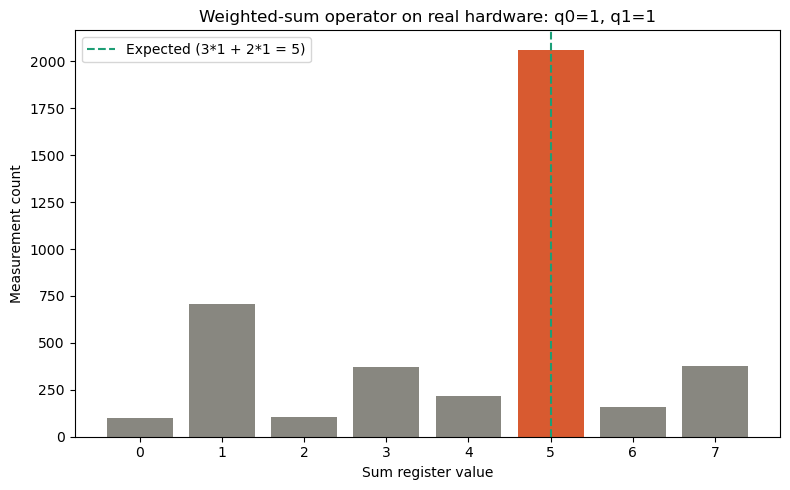

Fraction of shots reading the correct value (5): 50.34%


In [17]:
import matplotlib.pyplot as plt
from collections import defaultdict

# decode every measured bitstring into its 'sum' register value,
# not just the single most-frequent one
sum_counts = defaultdict(int)
for bitstring, count in hw_counts.items():
    reversed_bits = bitstring[::-1]
    idx = 0
    decoded = {}
    for name, size in zip(names, sizes):
        decoded[name] = reversed_bits[idx:idx+size][::-1]
        idx += size
    sum_val = int(decoded['sum'], 2)
    sum_counts[sum_val] += count

sum_values = sorted(sum_counts.keys())
counts = [sum_counts[v] for v in sum_values]

plt.figure(figsize=(8, 5))
colors = ['#D85A30' if v == 5 else '#888780' for v in sum_values]
bars = plt.bar(sum_values, counts, color=colors)
plt.axvline(5, color='#1D9E75', linestyle='--', linewidth=1.5, label='Expected (3*1 + 2*1 = 5)')
plt.xlabel('Sum register value')
plt.ylabel('Measurement count')
plt.title('Weighted-sum operator on real hardware: q0=1, q1=1')
plt.xticks(sum_values)
plt.legend()
plt.tight_layout()
plt.show()

total = sum(counts)
correct_fraction = sum_counts.get(5, 0) / total
print(f'Fraction of shots reading the correct value (5): {correct_fraction:.2%}')

## Results Summary

- The half-adder logic (CNOT for the sum bit, Toffoli for the carry bit) matches `CDKMRippleCarryAdder`'s own behavior exactly.
- `WeightedAdder` correctly computes `w1*q0 + w2*q1` for every combination of inputs, including the simultaneously-active case that exercises real carry propagation.
- Deriving per-qubit weights from a real weighted-price formula -- via symbolic expansion, then reading off each binary place's coefficient -- correctly reconstructs the true weighted basket value once the classically-computed baseline offset is added back.
- The same weighted-sum circuit runs correctly on real hardware, confirming this primitive is ready to be composed into a full basket-option `A` operator.

## What's Next

**Notebook 6** puts this weighted-sum operator to work pricing an actual **basket option**: two assets, distribution loading for each, the weighted-sum operator from this notebook combining them, and the same comparator-plus-payoff-rotation pipeline from Notebooks 3-4 applied to the combined register.